F1-RaceIQ-Suite: Data Loading -  loading the raw dataset, cleaning it, and exploring it visually

STEP-1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)

STEP-2: Loading the dataset

In [3]:
df = pd.read_csv("F1_RaceIQ_Dataset_1950_2024.csv")
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 7000 rows, 19 columns


STEP-3:First Look at the Data

In [4]:
df.head()

,Season,Round,Race Name,Date,Circuit,Country,Latitude,Longitude,Driver,Driver Nationality,Driver Age,Constructor,Grid Position,Race Position,Points Earned,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status
0,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Nino Farina,Italian,44,Alfa Romeo,1,1,9.0,NaN,-1,70,Finished
1,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Luigi Fagioli,Italian,52,Alfa Romeo,2,2,6.0,NaN,-1,70,Finished
2,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Reg Parnell,British,39,Alfa Romeo,4,3,4.0,NaN,-1,70,Finished
3,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Yves Cabantous,French,46,Talbot-Lago,6,4,3.0,NaN,-1,68,+2 Laps
4,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Louis Rosier,French,45,Talbot-Lago,9,5,2.0,NaN,-1,68,+2 Laps


In [5]:
df.dtypes

,0
Season,int64
Round,int64
Race Name,object
Date,object
Circuit,object
Country,object
Latitude,float64
Longitude,float64
Driver,object
Driver Nationality,object


In [6]:
df.shape

(7000, 19)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Season              7000 non-null   int64  
 1   Round               7000 non-null   int64  
 2   Race Name           7000 non-null   object 
 3   Date                7000 non-null   object 
 4   Circuit             7000 non-null   object 
 5   Country             7000 non-null   object 
 6   Latitude            7000 non-null   float64
 7   Longitude           7000 non-null   float64
 8   Driver              7000 non-null   object 
 9   Driver Nationality  7000 non-null   object 
 10  Driver Age          7000 non-null   int64  
 11  Constructor         7000 non-null   object 
 12  Grid Position       7000 non-null   int64  
 13  Race Position       7000 non-null   int64  
 14  Points Earned       7000 non-null   float64
 15  Fastest Lap (s)     2011 non-null   float64
 16  Fastes

In [8]:
df.describe()

,Season,Round,Latitude,Longitude,Driver Age,Grid Position,Race Position,Points Earned,Fastest Lap (s),Fastest Lap Rank,Laps Completed
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,2011.000000,7000.000000,7000.000000
mean,1987.985714,2.787571,18.189408,12.387964,30.390143,11.311429,11.369714,2.102713,93.033496,2.277143,52.479143
std,21.711649,1.340518,33.376960,65.915176,5.540219,6.906216,6.854489,4.307959,9.291641,6.047442,34.294379
min,1950.000000,1.000000,-37.849700,-118.189000,18.000000,0.000000,1.000000,0.000000,65.619000,-1.000000,0.000000
25%,1969.000000,2.000000,-23.703600,-43.395000,26.000000,5.000000,6.000000,0.000000,87.138000,-1.000000,31.000000
50%,1988.500000,3.000000,34.843100,6.947500,30.000000,11.000000,11.000000,0.000000,93.740000,-1.000000,56.000000
75%,2007.000000,4.000000,44.343900,39.104400,34.000000,17.000000,17.000000,2.000000,98.777500,3.000000,66.000000
max,2024.000000,7.000000,53.476900,144.968000,57.000000,33.000000,33.000000,26.000000,147.276000,24.000000,200.000000


Step 4 — Check for Missing, Zero, and Empty Values

In [9]:
nan_counts = df.isnull().sum()
zero_counts = (df == 0).sum()
empty_string_counts = (df == '').sum()

missing_values = pd.DataFrame({
    'NaN Count': nan_counts,
    'Zero Count': zero_counts,
    'Empty String Count': empty_string_counts
})

print(missing_values)

                    NaN Count  Zero Count  Empty String Count
Season                      0           0                   0
Round                       0           0                   0
Race Name                   0           0                   0
Date                        0           0                   0
Circuit                     0           0                   0
Country                     0           0                   0
Latitude                    0           0                   0
Longitude                   0           0                   0
Driver                      0           0                   0
Driver Nationality          0           0                   0
Driver Age                  0           0                   0
Constructor                 0           0                   0
Grid Position               0          98                   0
Race Position               0           0                   0
Points Earned               0        4624                   0
Fastest 

In [10]:
# Step 1: Try filling with circuit-specific mean
df['Fastest Lap (s)'] = df.groupby('Circuit')['Fastest Lap (s)'].transform(
    lambda x: x.fillna(x.mean())
)

# Step 2: Fallback — fill any still-remaining NaNs with the overall mean
df['Fastest Lap (s)'] = df['Fastest Lap (s)'].fillna(df['Fastest Lap (s)'].mean())

# Confirm
print("Remaining missing values:", df['Fastest Lap (s)'].isnull().sum())

Remaining missing values: 0


Step 5 — Handle Missing Values

In [11]:
print("Remaining missing values in 'Fastest Lap (s)':", df['Fastest Lap (s)'].isnull().sum())

Remaining missing values in 'Fastest Lap (s)': 0


Step 6 — Check for Duplicate Rows

In [12]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows found — dataset is already unique.")

Number of duplicate rows: 0
No duplicate rows found — dataset is already unique.


Step 7 — Identify Categorical and Numerical Columns

In [13]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", list(categorical_columns))

Categorical Columns: ['Race Name', 'Date', 'Circuit', 'Country', 'Driver', 'Driver Nationality', 'Constructor', 'Status']


In [14]:
numeric_columns = df.select_dtypes(include=['number']).columns
print("Numeric Columns:", list(numeric_columns))

Numeric Columns: ['Season', 'Round', 'Latitude', 'Longitude', 'Driver Age', 'Grid Position', 'Race Position', 'Points Earned', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed']


Step 8 — Detect Outliers (IQR Method)

Using the Interquartile Range (IQR) method to detect outliers in the numerical columns.

In [15]:
def detect_outliers_iqr(data, columns):
    outlier_counts = {}
    outlier_columns = []

    for column in columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
        outlier_counts[column] = outliers.shape[0]

        if outliers.shape[0] > 0:
            outlier_columns.append(column)

    return outlier_columns, outlier_counts


performance_columns = ['Driver Age', 'Grid Position', 'Race Position', 'Points Earned',
                        'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed']

outlier_columns, iqr_outliers = detect_outliers_iqr(df, performance_columns)
print("Columns with outliers detected:", outlier_columns)
print("\nOutlier counts per column:")
for col, count in iqr_outliers.items():
    print(f"  {col}: {count}")

Columns with outliers detected: ['Driver Age', 'Points Earned', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed']

Outlier counts per column:
  Driver Age: 61
  Grid Position: 0
  Race Position: 0
  Points Earned: 1084
  Fastest Lap (s): 3353
  Fastest Lap Rank: 1082
  Laps Completed: 229


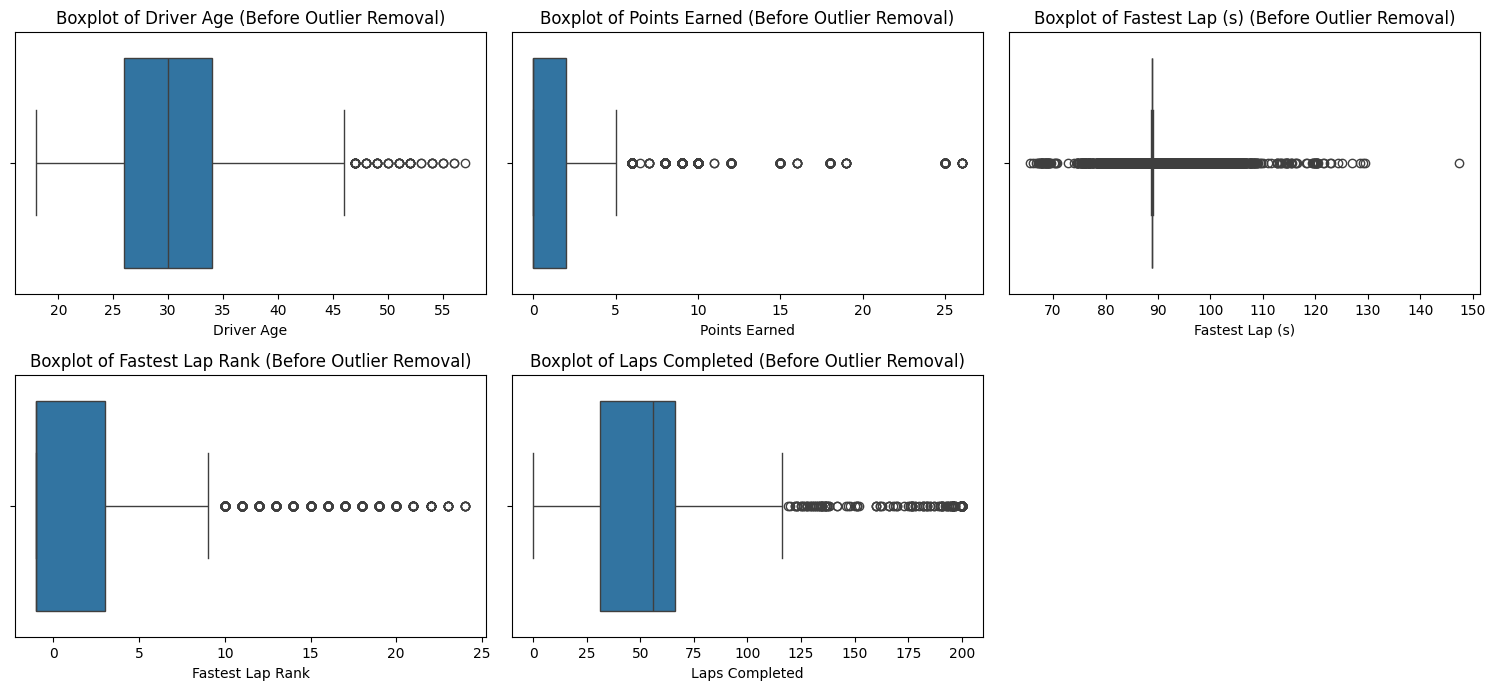

In [16]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (Before Outlier Removal)')
plt.tight_layout()
plt.show()

Step 9 — Remove Outliers (Selective)

In [17]:
columns_to_clean = ['Driver Age']

def remove_outliers_iqr(data, columns):
    for column in columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return data

df_cleaned = remove_outliers_iqr(df, columns_to_clean)
print(f"Shape before outlier removal: {df.shape}")
print(f"Shape after outlier removal: {df_cleaned.shape}")

Shape before outlier removal: (7000, 19)
Shape after outlier removal: (6939, 19)


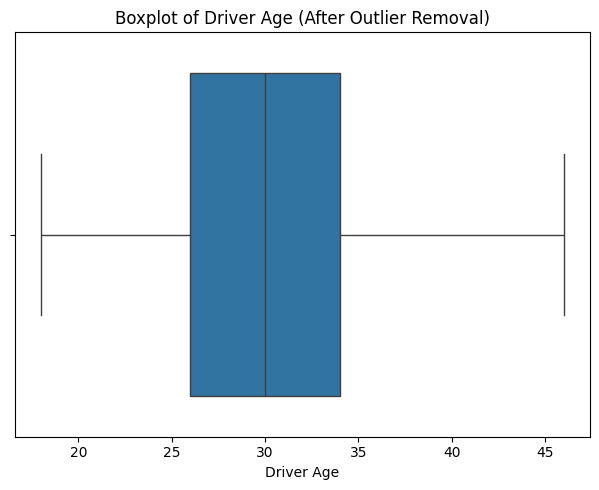

In [18]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(columns_to_clean, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df_cleaned[col])
    plt.title(f'Boxplot of {col} (After Outlier Removal)')
plt.tight_layout()
plt.show()

Step 10 — Save the Cleaned Dataset

In [19]:
df_cleaned.to_csv('cleaned_f1_data.csv', index=False)
print("Cleaned dataset saved as 'cleaned_f1_data.csv'")
print(f"Final shape: {df_cleaned.shape}")

Cleaned dataset saved as 'cleaned_f1_data.csv'
Final shape: (6939, 19)


Step 11 — Exploratory Data Analysis (EDA)

11.1 — Distribution of Driver Age

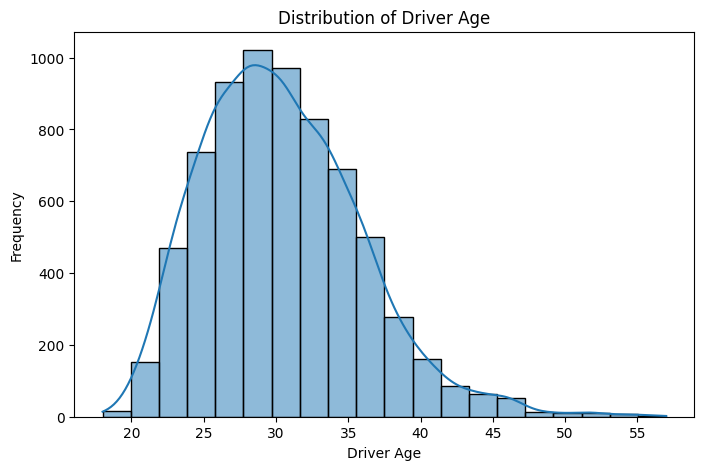

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Driver Age'], bins=20, kde=True)
plt.title('Distribution of Driver Age')
plt.xlabel('Driver Age')
plt.ylabel('Frequency')
plt.show()

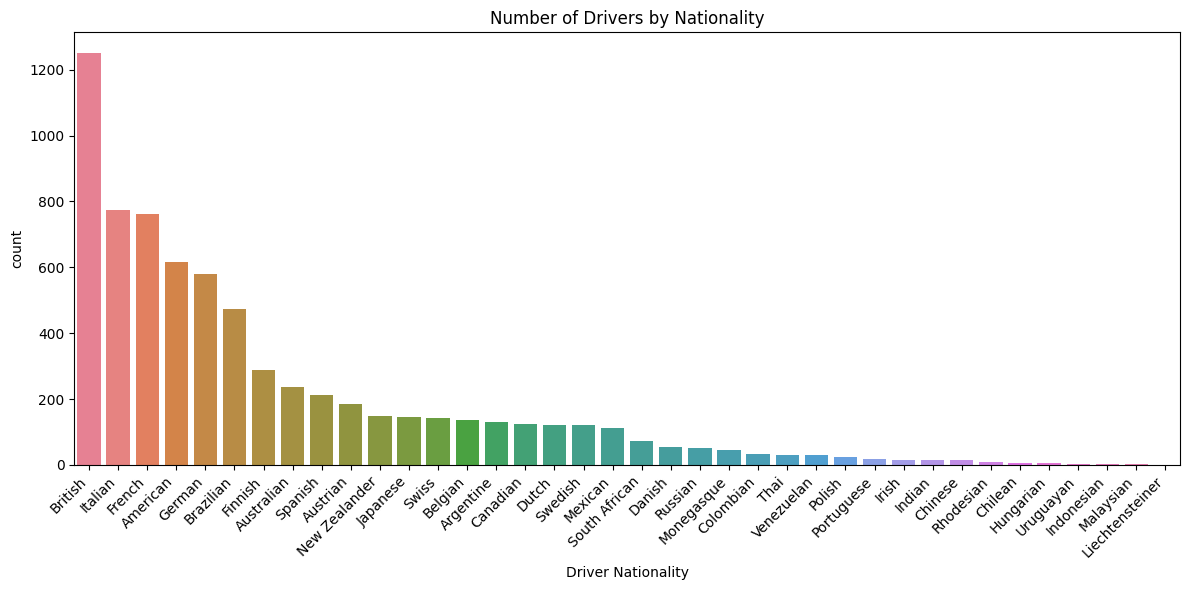

In [21]:
plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl", n_colors=df['Driver Nationality'].nunique())

sns.countplot(x='Driver Nationality',
              data=df,
              order=df['Driver Nationality'].value_counts().index,
              palette=colors)

plt.title('Number of Drivers by Nationality')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

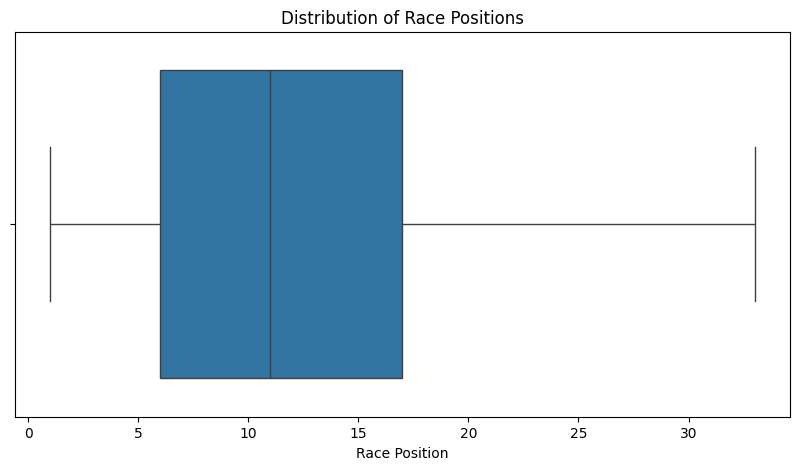

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Race Position', data=df)
plt.title('Distribution of Race Positions')
plt.xlabel('Race Position')
plt.show()

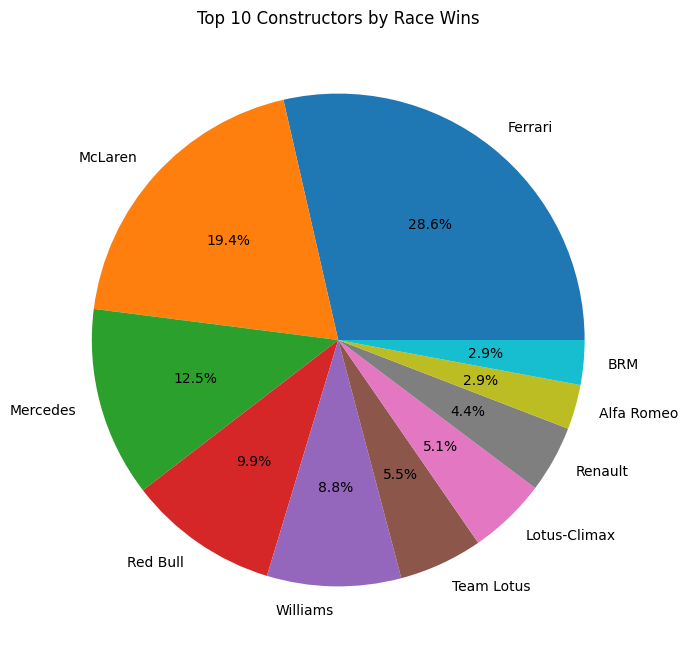

In [23]:
winners_df = df[df['Race Position'] == 1]
constructor_wins = winners_df['Constructor'].value_counts().head(10)

plt.figure(figsize=(8, 8))
constructor_wins.plot.pie(autopct='%1.1f%%', legend=False)
plt.title('Top 10 Constructors by Race Wins')
plt.ylabel('')
plt.show()

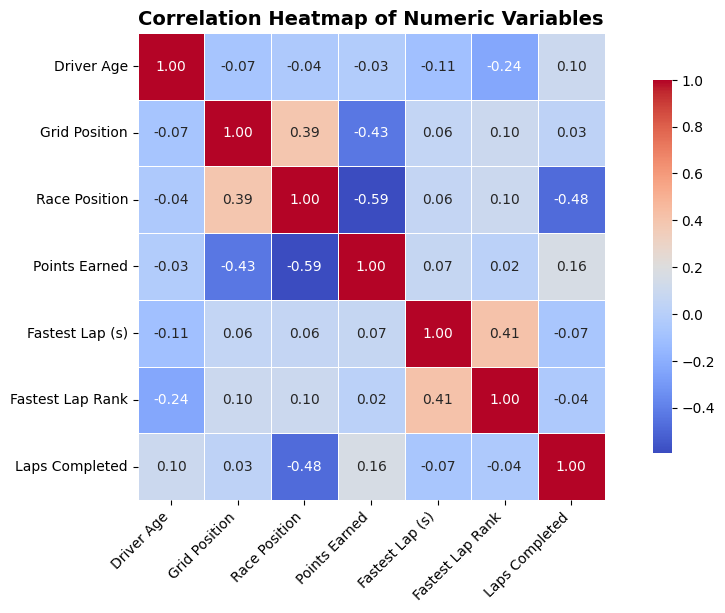

In [24]:
corr_columns = ['Driver Age', 'Grid Position', 'Race Position', 'Points Earned',
                'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed']

corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14, fontweight='bold')
plt.show()

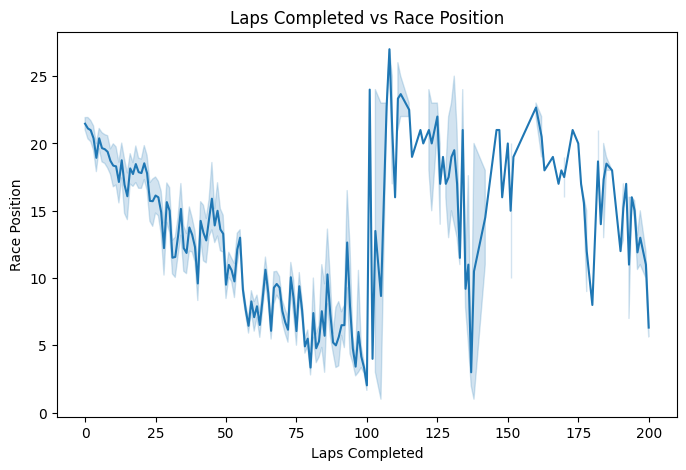

In [25]:
plt.figure(figsize=(8,5))
sns.lineplot(x='Laps Completed', y='Race Position', data=df)
plt.title('Laps Completed vs Race Position')
plt.xlabel('Laps Completed')
plt.ylabel('Race Position')
plt.show()

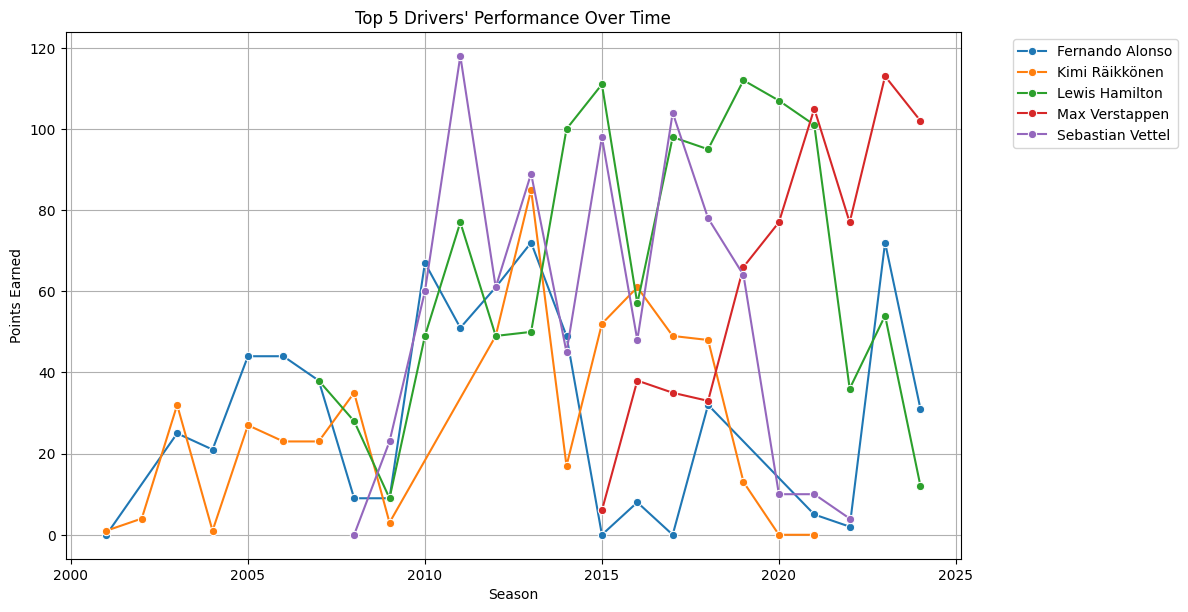

In [26]:
driver_yearly_points = df.groupby(['Driver', 'Season'])['Points Earned'].sum().reset_index()

top_drivers = (driver_yearly_points.groupby('Driver')['Points Earned']
               .sum().sort_values(ascending=False).head(5).index)

top_drivers_df = driver_yearly_points[driver_yearly_points['Driver'].isin(top_drivers)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=top_drivers_df, x='Season', y='Points Earned', hue='Driver', marker='o')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.title('Top 5 Drivers\' Performance Over Time')
plt.grid(True)
plt.show()

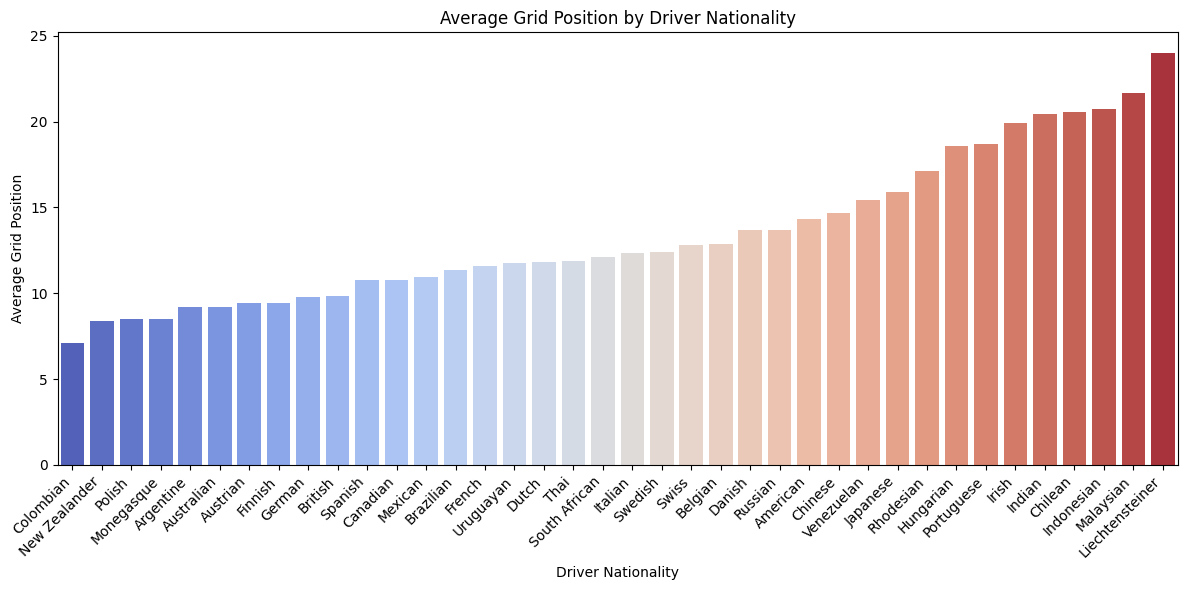

In [27]:
average_grid_position = df.groupby("Driver Nationality")["Grid Position"].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(x=average_grid_position.index, y=average_grid_position.values, palette="coolwarm")
plt.title("Average Grid Position by Driver Nationality")
plt.xlabel("Driver Nationality")
plt.ylabel("Average Grid Position")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()